# Dataclasses and the Linear Reservoir

In this notebook you will learn how to bundle named fields into a single value, and how to describe a hydrological system as a pure transition between states.

By the end of the notebook, you should be able to:

- use `@dataclass` to define a named bundle of fields
- create a dataclass instance and read its fields with dot access
- pass a dataclass into a function as a single typed argument
- explain what a state-space model is: state, inputs, parameters, transition function
- write the equations of a linear reservoir and describe what the residence time `k` controls
- represent `State` and `Parameters` as dataclasses
- write a transition function `step(state, inflow, params) -> (new_state, outflow)` that returns a new state instead of mutating the old one
- run a linear reservoir for many days over a NumPy array of inflow
- compare the response of a flashy reservoir (small `k`) and a slow reservoir (large `k`)
- connect this minimal model to the groundwater store of the real bucket-model we will use later in the course

## How To Use This Notebook

This notebook mixes explanation, code, and short interpretations.

Suggested rhythm:

- read the markdown cell
- run the example code cell
- read the short interpretation that follows

There are no separate exercise cells in this notebook. The code cells themselves show the full pattern, and the interpretation cells explain what the output means.

Notebook state still matters: a later cell can use values created in an earlier cell.

Type hints appear on all function signatures, as introduced in notebook 04. A dataclass name used as a type hint — for example `Basin` or `State` — is read the same way: it means "this parameter is an instance of that bundle of fields."

This notebook assumes notebooks 04, 05, and 06 have been read. We will reload the Alamedin precipitation and cleaned streamflow CSVs in the second half, so make sure notebook 05 has been run at least once so `alamedin_cleaned_daily.csv` exists on disk.

## 1. Setup: Imports, Paths, And Constants

Same imports as notebooks 05 and 06, plus one new name from the standard library: `dataclass` from the `dataclasses` module. That decorator is the single new piece of machinery this notebook introduces.

We carry the basin constants forward from notebook 06 — `ALAMEDIN_AREA_KM2` and `ALAMEDIN_GAUGE_LAT_DEG` — because we will wrap them into a small dataclass in the next section.

In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_ROOT = Path.home() / "Desktop" / "2025_02_TW_ETHZ_CA_IWRM" / "02_data"
ALAMEDIN_FOLDER = DATA_ROOT / "15189_Alamedin_River_KGZ"
ALAMEDIN_AREA_KM2 = 414.05
ALAMEDIN_GAUGE_LAT_DEG = 42.697

print(DATA_ROOT)
print(ALAMEDIN_FOLDER.exists())

/Users/nicolaslazaro/Desktop/2025_02_TW_ETHZ_CA_IWRM/02_data
True


`ALAMEDIN_FOLDER.exists()` returns `True`. We will not load any CSVs until the second half of the notebook — the first five sections are about structure and math.

## 2. Why Bundle Data? A Small `Basin` Dataclass

A catchment has several numbers that always travel together: its name, its drainage area, its gauge latitude. So far we have carried these as separate constants — `ALAMEDIN_AREA_KM2`, `ALAMEDIN_GAUGE_LAT_DEG`, and a name kept in prose. Any function that needs all three has to list all three in its signature.

This gets clumsy fast. A cleaner approach is to group the fields into a single named value.

Python's `@dataclass` does exactly that. It takes a short block of field names and types and turns it into a small, reusable bundle. You do not need to know how the machinery works under the hood — for this course, treat `@dataclass` as the recipe that produces a named bundle of fields.

The syntax is three parts:

- the line `@dataclass` just above the bundle
- the word `class` followed by the bundle's name
- one line per field, in the form `field_name: type`

In [2]:
@dataclass
class Basin:
    name: str
    area_km2: float
    gauge_lat_deg: float

The cell ran silently. That is expected. `@dataclass` defines the recipe for the bundle; it does not yet build one. The next cell creates an actual `Basin` value for Alamedin.

In [3]:
alamedin = Basin(
    name="Alamedin",
    area_km2=ALAMEDIN_AREA_KM2,
    gauge_lat_deg=ALAMEDIN_GAUGE_LAT_DEG,
)

print(alamedin)
print(alamedin.name)
print(alamedin.area_km2)
print(alamedin.gauge_lat_deg)

Basin(name='Alamedin', area_km2=414.05, gauge_lat_deg=42.697)
Alamedin
414.05
42.697


Two useful facts come out of this cell.

First, `@dataclass` gives us a readable printed form for free: `Basin(name='Alamedin', area_km2=414.05, gauge_lat_deg=42.697)`. No formatting code was written. This is handy when inspecting values in the notebook.

Second, fields are read with dot access: `alamedin.name`, `alamedin.area_km2`. This is the same `.` you already use on a pandas Series (`s.mean()`) or a NumPy array (`arr.shape`). The three fields are now glued to the single name `alamedin` and can be passed around as one value.

In [4]:
def describe(basin: Basin) -> str:
    return f"{basin.name}: {basin.area_km2} km\u00b2, gauge at {basin.gauge_lat_deg}\u00b0 N"


print(describe(alamedin))

Alamedin: 414.05 km², gauge at 42.697° N


Compare the signature `describe(basin: Basin) -> str` with the version we would have written without a dataclass: `describe(name: str, area_km2: float, gauge_lat_deg: float) -> str`. The dataclass version has one argument instead of three, and the type hint `Basin` tells the reader exactly which fields are available inside.

If later we add `mean_elevation_m` to `Basin`, every function that already accepts a `Basin` keeps working. The signature does not change. This is the practical payoff of grouping fields.

In [5]:
@dataclass
class BasinWithLapse:
    name: str
    area_km2: float
    gauge_lat_deg: float
    lapse_rate_c_per_m: float = 0.006


alamedin_v2 = BasinWithLapse(
    name="Alamedin",
    area_km2=ALAMEDIN_AREA_KM2,
    gauge_lat_deg=ALAMEDIN_GAUGE_LAT_DEG,
)

print(alamedin_v2)
print(alamedin_v2.lapse_rate_c_per_m)

BasinWithLapse(name='Alamedin', area_km2=414.05, gauge_lat_deg=42.697, lapse_rate_c_per_m=0.006)
0.006


Fields can have default values, exactly like function parameters in notebook 04. The field `lapse_rate_c_per_m: float = 0.006` means: if the caller does not supply a value, `0.006` is used. Fields with defaults must appear after fields without defaults.

The value `0.006 °C/m` is the standard atmospheric lapse rate. It will reappear later in this course when we start caring about elevation corrections.

## 3. State-Space Models

Before we write any hydrology, we need a vocabulary for describing a system that evolves over time.

A dynamical system's behaviour at time $t+1$ depends on three things:

- its **state** at time $t$ — the internal variables that the system "remembers" (how much water is currently stored in the bucket)
- the **inputs** arriving at time $t$ — external forcings (today's rainfall, today's temperature)
- fixed **parameters** — numbers that do not change over time (the residence time, the maximum soil capacity)

Given those three, a **transition function** produces the next state and an observable output:

$$
x(t{+}1),\; y(t) \;=\; f\!\big(x(t),\; u(t),\; \theta\big)
$$

The symbols:

- $x$ — state (what the system remembers)
- $u$ — input (what arrives from outside)
- $\theta$ — parameters (fixed numbers that define the system)
- $y$ — output (what we observe — for a river, streamflow)
- $f$ — transition function (pure math from the current situation to the next)

This is the **state-space** view. It is a way of thinking, not a specific model. Any dynamical system — a water tank, an electrical circuit, an economy, a catchment — can be written this way.

Three properties of this framing are worth naming now, because they will shape every line of code in the second half of this notebook:

- **The state is small and named.** Not every number in the system is state. State is exactly the set of variables that the transition function needs from the previous timestep to produce the next one. For a single bucket, that is just the current storage.
- **The transition function is pure.** It takes the old state and the inputs, and returns the new state. It does not secretly modify anything in the background. Given the same inputs, it always produces the same outputs.
- **Parameters and state are different things.** Parameters are fixed across the simulation (they describe the catchment). State changes every timestep (it describes the situation right now). Mixing them up is one of the most common modelling bugs.

The mapping to Python is direct:

- state → a dataclass named `State`
- parameters → a dataclass named `Parameters`
- inputs → scalar arguments (today's rainfall, today's temperature) or a NumPy array for a whole record
- the transition function → an ordinary Python function with the signature `step(state, inputs, params) -> (new_state, output)`

Python's `@dataclass` is a clean fit because it isolates *what the system remembers* from *how it evolves*. The remembering lives in `State`; the evolving lives in the function. There is no hidden state, no mutable global, and no ambiguity about which numbers are constants and which are time-varying.

## 4. The Linear Reservoir

The simplest useful state-space model in hydrology is the **linear reservoir**: a bucket with a hole, where the outflow is proportional to the current storage.

The continuous form is a mass balance plus a linear outflow law.

Mass balance (storage changes with the difference between inflow and outflow):

$$
\frac{dS}{dt} = I(t) - Q(t)
$$

Linear outflow (drainage is proportional to current storage):

$$
Q(t) = \frac{S(t)}{k}
$$

$S$ is the current storage in mm. $I$ is the inflow in mm/day. $Q$ is the outflow in mm/day. $k$ has units of time (days) and is the **mean residence time** — the average time a water molecule stays in the bucket before draining. The two equations together fully specify the system: given $k$, an initial storage, and a series of inflows, everything else is determined.

### Daily Discretisation

In practice, we solve the equations on a daily grid. The discrete form uses the storage at the end of the previous day to compute today's outflow, then updates the storage:

$$
Q(t) = \frac{S(t-1)}{k}
$$

$$
S(t) = S(t-1) + I(t) - Q(t)
$$

These are the two equations that the code in the second half of this notebook implements. They are exactly the linear-reservoir form used by the groundwater store of the bucket-model we will study later in the course.

### What `k` Controls

`k` has a clean physical meaning: it is the number of days of storage the bucket holds at steady state per unit of outflow. It also controls how fast a pulse of inflow is smoothed.

Two regimes to keep in mind:

- **Small `k` (around 1–5 days)**: a flashy reservoir. A rain event shows up in the outflow almost the same day. Storage drains rapidly. This is the behaviour of a small, steep catchment on impermeable bedrock.
- **Large `k` (around 30–100 days)**: a slow reservoir. A rain event shows up in the outflow weeks later, stretched out over time. Storage drains slowly. This is the behaviour of a deep groundwater aquifer.

The linear reservoir has one state variable (`S`) and one parameter (`k`). This is the minimum machinery needed for a model that has memory — the minimum non-trivial state-space system. For that reason it is worth understanding completely before stacking more pieces on top.

### A Single Step By Hand

Before we wrap any of this in a dataclass, it helps to do one step on scalar values. The arithmetic is small; the point is to make the two equations concrete.

Suppose the bucket starts with `storage_mm = 50.0` and has a residence time of `k_days = 10.0`. Today's inflow is `inflow_mm = 4.0`. Compute today's outflow and tomorrow's storage.

In [6]:
k_days = 10.0
storage_mm = 50.0
inflow_mm = 4.0

outflow_mm = storage_mm / k_days
new_storage_mm = storage_mm + inflow_mm - outflow_mm

print("outflow_mm    =", outflow_mm)
print("new_storage_mm =", new_storage_mm)

outflow_mm    = 5.0
new_storage_mm = 49.0


In [7]:
storage_mm = new_storage_mm
inflow_mm = 0.0

outflow_mm = storage_mm / k_days
new_storage_mm = storage_mm + inflow_mm - outflow_mm

print("day 2 outflow_mm    =", outflow_mm)
print("day 2 new_storage_mm =", new_storage_mm)

day 2 outflow_mm    = 4.9
day 2 new_storage_mm = 44.1


Three things are worth reading off these two cells.

- **Day 1 outflow is `5.0 mm/day`**, computed as `50.0 / 10.0`. Outflow depends only on the previous day's storage and on `k`.
- **Day 1 ends with `49.0 mm` of storage**, because inflow `4.0` slightly undershoots outflow `5.0`. The bucket lost `1.0 mm` net.
- **Day 2, with zero inflow, drops outflow to `4.9 mm/day` and storage to `44.1 mm`.** With no input, storage decays by a factor of `(1 − 1/k)` each day. At `k = 10`, that is a 10% drop per day — classic exponential-like recession.

We wrote this by reassigning `storage_mm` in each cell. That works for two days. For a 7305-day record, we need something more structured: a dataclass that holds the state, a pure function that advances it by one timestep, and a loop over the inflow series. That is exactly what the next sections of this notebook build.

## 5. Parameters and State as Dataclasses

The state-space framing in section 3 split the model into two kinds of things: **parameters** $\theta$, which are fixed numbers we would calibrate once and keep; and **state** $x(t)$, which is what the bucket remembers from one day to the next.

For the linear reservoir, $\theta$ and $x$ each have exactly one number:

- parameters: the residence time `k` in days
- state: the current storage `S` in millimetres

That is small enough that we could carry them as loose floats. We will not. From here on, parameters and state each get their own `@dataclass`. The two reasons are the same two reasons that motivated `@dataclass` back in section 2:

- **the field name tells you the unit** — `k_days` and `storage_mm` are self-labelling
- **the type tells you the role** — a function that takes `Parameters` cannot be handed a `State` by mistake, even though both are "just one float"

This is the pattern we want to teach you. In the final exercise, `Parameters` carries five fields and `State` carries three. Here we start with one each.

In [8]:
@dataclass
class Parameters:
    k_days: float


@dataclass
class State:
    storage_mm: float = 0.0

Two small classes. Read them as labels on what the model holds:

- `Parameters.k_days` is $\theta$ — the residence time of the reservoir. Bigger `k` means water sits in the bucket longer.
- `State.storage_mm` is $x(t)$ — how much water is in the bucket right now. It defaults to `0.0` because an empty bucket is a sensible starting point; we can override it when we want to.

`Parameters` is what we would calibrate against gauge data. `State` is what the simulation updates once per day.

In [9]:
params_example = Parameters(k_days=10.0)
state_example = State(storage_mm=50.0)
state_default = State()

print(params_example)
print(state_example)
print(state_default)
print()
print("k_days:      ", params_example.k_days)
print("storage_mm:  ", state_example.storage_mm)
print("default S_0: ", state_default.storage_mm)

Parameters(k_days=10.0)
State(storage_mm=50.0)
State(storage_mm=0.0)

k_days:       10.0
storage_mm:   50.0
default S_0:  0.0


Each `print` shows the class name and the fields — the free repr that `@dataclass` gives us. `State()` with no argument lands on `storage_mm=0.0` because of the default. That default is what we will use when we start a simulation "cold", with no water in the bucket.

## 6. The Transition Function

Section 3 wrote the state-space transition as

$$
x(t+1),\; y(t) \;=\; f\big(x(t),\, u(t),\, \theta\big)
$$

and section 4 wrote the linear-reservoir equations as

$$
Q(t) \;=\; \frac{S(t-1)}{k}, \qquad S(t) \;=\; S(t-1) \,+\, I(t) \,-\, Q(t).
$$

In this section we put those two things together in a single Python function called `step`. It consumes the current `State`, the `Parameters`, and today's inflow, and returns:

- the new `State` — that is $x(t+1)$
- the outflow — that is $y(t)$

One rule we will hold ourselves to: `step` **never mutates** the state it was handed. It constructs a fresh `State` object and returns it. The old state stays exactly as it was. This is the move that makes the state-space picture concrete in code — each call to `step` is a clean transition from one state to the next, with the previous state still available if we need it.

In [10]:
def step(state: State, params: Parameters, inflow_mm: float) -> tuple[State, float]:
    outflow_mm = state.storage_mm / params.k_days
    new_storage_mm = state.storage_mm + inflow_mm - outflow_mm
    new_state = State(storage_mm=new_storage_mm)
    return new_state, outflow_mm

Four lines, read from top to bottom:

1. `outflow_mm = state.storage_mm / params.k_days` — the linear-reservoir law. Today's outflow is yesterday's storage divided by the residence time.
2. `new_storage_mm = state.storage_mm + inflow_mm - outflow_mm` — the water balance. Start with yesterday's storage, add the inflow that arrived today, subtract what drained out.
3. `new_state = State(storage_mm=new_storage_mm)` — **a fresh `State`**. This is the key move. We do not assign back into `state.storage_mm`; we construct a new object.
4. `return new_state, outflow_mm` — hand back both the next state and today's outflow, as a tuple.

The signature `-> tuple[State, float]` says exactly that: one `State` and one `float`, always in that order.

In [11]:
s0 = State(storage_mm=50.0)
p = Parameters(k_days=10.0)

s1, q1 = step(s0, p, inflow_mm=0.0)

print("before:", s0)
print("after: ", s1)
print("outflow today:", q1, "mm")

before: State(storage_mm=50.0)
after:  State(storage_mm=45.0)
outflow today: 5.0 mm


Two things to notice.

**The physics.** The bucket held `50 mm`. With `k = 10 days`, one tenth of the storage drains in a day — `5 mm`. No inflow arrived, so after the step the bucket holds `50 - 5 = 45 mm`. The linear-reservoir law in action.

**The non-mutation.** `s0` still prints as `State(storage_mm=50.0)`. The function built a new object, `s1`, and left the original alone. This is why we can talk about "the state at day 0" and "the state at day 1" as separate things: they are separate Python objects. No step of the simulation ever reaches back and rewrites a previous day.

## 7. Experiment 1: Pulse Response

Residence time `k` has units of days. That much we know from section 4. But what does `k = 5` feel like compared to `k = 30`? The quickest way to build that intuition is to dump one fixed amount of water into an empty bucket on day 0, send nothing afterward, and watch the bucket drain.

After the initial pulse lands, inflow is zero from day 1 onward. The water balance from section 6 then simplifies to

$$
S(t) \;=\; S(t-1) - \tfrac{S(t-1)}{k} \;=\; S(t-1)\left(1 - \tfrac{1}{k}\right),
$$

which iterates to the exponential decay

$$
S(t) \;=\; S(0) \,\left(1 - \tfrac{1}{k}\right)^{t}.
$$

We will run the simulation for 60 days with a single `100 mm` pulse on day 0, for three residence times: `k = 5, 10, 30 days`.

To run the reservoir for `n` days we wrap `step` in a small loop. The driver below does two bookkeeping jobs on top of calling `step`:

- carry the state from one day to the next, by overwriting `state` with the `new_state` that `step` returned
- record every day's storage and outflow into two NumPy arrays so we can plot them afterwards

The function itself does no hydrology — that all lives in `step`. This is the pattern we will reuse in the next section on real precipitation.

In [ ]:
n_days = 60

inflow_series_mm = np.zeros(n_days)
inflow_series_mm[0] = 100.0


def run_linear_reservoir(params: Parameters, inflow_series_mm: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    storage_history_mm = np.zeros(len(inflow_series_mm))
    outflow_history_mm = np.zeros(len(inflow_series_mm))
    state = State(storage_mm=0.0)

    for i, inflow in enumerate(inflow_series_mm):
        state, outflow = step(state, params, inflow)
        storage_history_mm[i] = state.storage_mm
        outflow_history_mm[i] = outflow

    return storage_history_mm, outflow_history_mm


print("inflow shape:", inflow_series_mm.shape)
print("inflow[:5]:  ", inflow_series_mm[:5])

inflow shape: (60,)
inflow[:5]:   [100.   0.   0.   0.   0.]


In [ ]:
k_values_days = [5.0, 10.0, 30.0]

pulse_runs: dict[float, tuple[np.ndarray, np.ndarray]] = {
    k: run_linear_reservoir(Parameters(k_days=k), inflow_series_mm) for k in k_values_days
}

for k, (storage, outflow) in pulse_runs.items():
    print(
        f"k = {k:>4.0f} days | peak Q = {outflow.max():5.2f} mm on day {outflow.argmax():>2}"
        f" | Q on day 30 = {outflow[30]:6.3f} mm"
    )

k =    5 days | peak Q = 20.00 mm on day  1 | Q on day 30 =  0.031 mm
k =   10 days | peak Q = 10.00 mm on day  1 | Q on day 30 =  0.471 mm
k =   30 days | peak Q =  3.33 mm on day  1 | Q on day 30 =  1.247 mm


Three peaks, one per `k`, all on day 1. That already tells us something: `k` sets not when the peak happens (always the day after the pulse, here) but how **tall** it is and how **fast** it decays.

To see the whole shape, not just the peak, we plot storage and outflow over the full 60 days, one panel each, three lines per panel. Sharing the x-axis makes the top/bottom alignment easy to read.

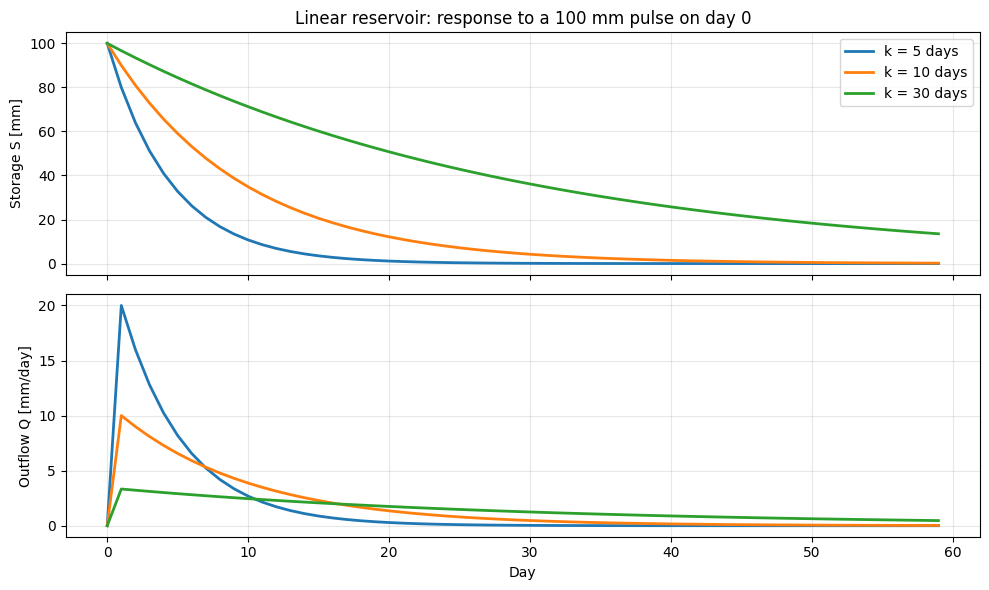

Saved figure to: /Users/nicolaslazaro/Desktop/work/wat-mod-GIZ/notebooks/figures/linear_reservoir_pulse_response.png


In [14]:
figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

days_axis = np.arange(n_days)

fig, (ax_storage, ax_outflow) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for k, (storage, outflow) in pulse_runs.items():
    ax_storage.plot(days_axis, storage, label=f"k = {k:.0f} days", linewidth=2)
    ax_outflow.plot(days_axis, outflow, label=f"k = {k:.0f} days", linewidth=2)

ax_storage.set_ylabel("Storage S [mm]")
ax_storage.set_title("Linear reservoir: response to a 100 mm pulse on day 0")
ax_storage.grid(alpha=0.3)
ax_storage.legend()

ax_outflow.set_xlabel("Day")
ax_outflow.set_ylabel("Outflow Q [mm/day]")
ax_outflow.grid(alpha=0.3)

fig.tight_layout()

output_path = figures_dir / "linear_reservoir_pulse_response.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {output_path.resolve()}")

Three patterns jump out.

**Small `k` is flashy.** With `k = 5 days`, the outflow peaks at `20 mm/day` on day 1 and is down to `0.03 mm/day` by day 30. The bucket empties quickly.

**Large `k` is slow and low.** With `k = 30 days`, the same `100 mm` pulse peaks at only `3.3 mm/day` and is still putting out `1.25 mm/day` on day 30 — more than forty times the day-30 flow of the `k = 5` bucket. The water is there, it is just leaving in a thin, long tail.

**Total water out is conserved.** All three curves integrate to `100 mm` over a long enough horizon. `k` redistributes the pulse in time; it does not change the total.

This is what a residence time **is**: it controls the shape of the hydrograph response to an input. A groundwater store with a long residence time turns a pulse of recharge into months of slow baseflow.

## 8. Experiment 2: Real Alamedin Precipitation, 2015

A synthetic pulse is good for intuition. A real forcing series is the test of whether that intuition survives contact with data.

We will run the same `step`, the same `run_linear_reservoir` driver, and the same `Parameters` + `State` dataclasses on a full year of daily ERA5 precipitation over the Alamedin catchment. Year 2015 is a natural pick: notebook 06 showed that 2015 had the highest July mean discharge of any year in the record (`5.37 mm/day`), driven by a cluster of late-July events. If the linear reservoir captures that peak, it captures something real. If it misses it, we learn something too.

We will pick `k = 15 days` as a one-shot guess — defensible for a mountain catchment groundwater store, but not calibrated. This is an experiment, not a model fit.

In [15]:
precip_path = ALAMEDIN_FOLDER / "02_forcing" / "era5_precipitation_daily.csv"

precip_df = pd.read_csv(precip_path, parse_dates=["date"])
precip_2015_df = precip_df.loc[precip_df["date"].dt.year == 2015].copy()

print("2015 precip rows:", len(precip_2015_df))
print("date range:", precip_2015_df["date"].min().date(), "to", precip_2015_df["date"].max().date())
print(f"min daily precip: {precip_2015_df['precipitation_mm'].min():.2f} mm")
print(f"max daily precip: {precip_2015_df['precipitation_mm'].max():.2f} mm")
print(f"annual total:     {precip_2015_df['precipitation_mm'].sum():.1f} mm")

2015 precip rows: 365
date range: 2015-01-01 to 2015-12-31
min daily precip: 0.00 mm
max daily precip: 28.67 mm
annual total:     1276.8 mm


`365` daily values, spanning all of 2015. Annual total of `1277 mm` — consistent with what notebook 05 showed for an Alamedin precipitation year. The wettest single day hits nearly `29 mm`.

In [ ]:
params_2015 = Parameters(k_days=15.0)
inflow_2015_mm = precip_2015_df["precipitation_mm"].values

storage_2015_mm, simulated_q_2015_mm = run_linear_reservoir(params_2015, inflow_2015_mm)

print("simulated output shape:", simulated_q_2015_mm.shape)
print(
    f"peak simulated Q: {simulated_q_2015_mm.max():.2f} mm/day"
    f" on {precip_2015_df['date'].iloc[simulated_q_2015_mm.argmax()].date()}"
)
print(f"annual simulated Q total: {simulated_q_2015_mm.sum():.1f} mm")

simulated output shape: (365,)
peak simulated Q: 10.14 mm/day on 2015-07-25
annual simulated Q total: 1264.8 mm


In [17]:
q_path = ALAMEDIN_FOLDER / "03_processed" / "alamedin_cleaned_daily.csv"

q_df = pd.read_csv(q_path, parse_dates=["date"])

q_2015_df = q_df.loc[
    (q_df["date"].dt.year == 2015) & (q_df["q_status"] == "observed")
].copy()

print("2015 observed rows:", len(q_2015_df))
print(f"peak observed Q:  {q_2015_df['q_mm_clean'].max():.2f} mm/day"
      f" on {q_2015_df.loc[q_2015_df['q_mm_clean'].idxmax(), 'date'].date()}")
print(f"annual observed Q total: {q_2015_df['q_mm_clean'].sum():.1f} mm")

2015 observed rows: 365
peak observed Q:  6.47 mm/day on 2015-07-23
annual observed Q total: 540.9 mm


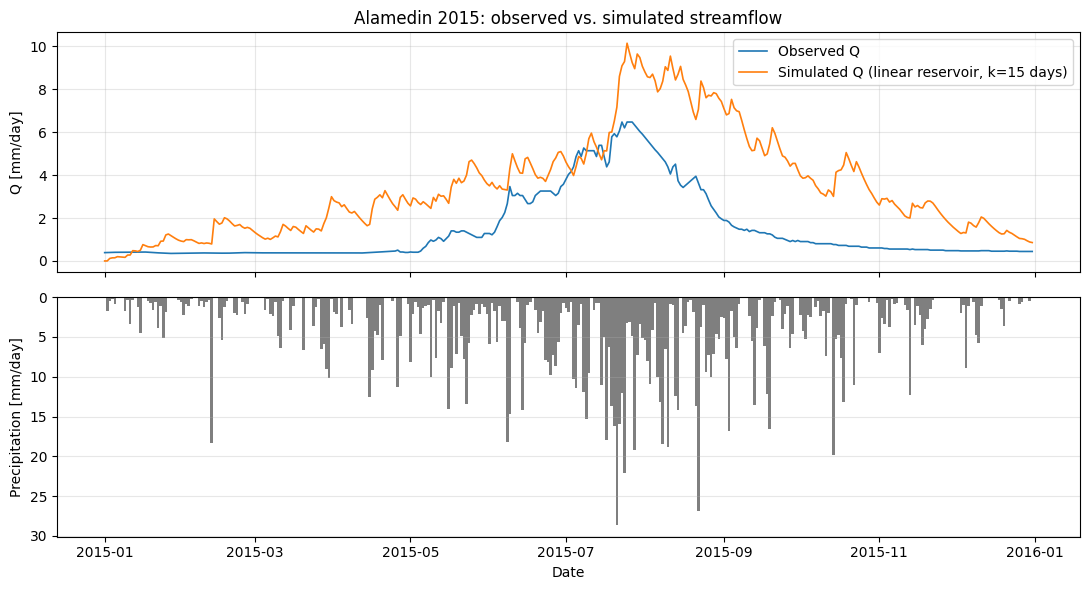

Saved figure to: /Users/nicolaslazaro/Desktop/work/wat-mod-GIZ/notebooks/figures/linear_reservoir_alamedin_2015.png


In [18]:
fig, (ax_q, ax_p) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax_q.plot(q_2015_df["date"], q_2015_df["q_mm_clean"],
          color="tab:blue", linewidth=1.2, label="Observed Q")
ax_q.plot(precip_2015_df["date"], simulated_q_2015_mm,
          color="tab:orange", linewidth=1.2, label="Simulated Q (linear reservoir, k=15 days)")

ax_q.set_ylabel("Q [mm/day]")
ax_q.set_title("Alamedin 2015: observed vs. simulated streamflow")
ax_q.grid(alpha=0.3)
ax_q.legend(loc="upper right")

ax_p.bar(precip_2015_df["date"], precip_2015_df["precipitation_mm"],
         color="tab:gray", width=1.0)
ax_p.set_ylabel("Precipitation [mm/day]")
ax_p.set_xlabel("Date")
ax_p.grid(axis="y", alpha=0.3)
ax_p.invert_yaxis()

fig.tight_layout()
output_path = figures_dir / "linear_reservoir_alamedin_2015.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {output_path.resolve()}")

One things to read off the plot.

**Simulated annual Q is much larger than observed.** The bucket passes nearly all `1277 mm` of precipitation through as outflow (minus a small amount still in storage at year-end), while the observed annual Q is only `541 mm`. The missing `~700 mm` left the catchment as evapotranspiration — a process the linear reservoir has no notion of.

Two structural gaps become concrete here:

- **No evapotranspiration.** Water comes in and must come out on the same timescale as `k`. There is no sink, so annual mass balance cannot match a catchment where half of annual precipitation is lost to ET.
- **No snow.** For a snowmelt-driven year, a linear reservoir cannot delay winter precipitation to release it as a summer melt pulse.

This is why the next notebook adds a **soil bucket with ET losses** and a **snow bucket with accumulation and melt** on top of the reservoir we just built.

## Wrap-Up

You can now:

- define a small `@dataclass` to carry model parameters (one field: `k_days`)
- define a small `@dataclass` to carry model state, with a sensible default (`storage_mm: float = 0.0`)
- read a model as a state-space system: $x(t+1), y(t) = f(x(t), u(t), \theta)$
- write a linear-reservoir transition as a pure function `step(state, params, inflow_mm)` that returns a **new** `State` rather than mutating the old one
- wrap `step` in a short driver loop to simulate any inflow series
- build a synthetic pulse experiment and read residence time `k` off the shape of the response
- run the same code on real ERA5 precipitation over a full year and plot simulated versus observed discharge
- diagnose a structural model failure by comparing the simulated hydrograph to the observed one, and identify what the model is missing

In the next notebook, we add a snow bucket and a soil bucket to this same pattern, assemble them into the full bucket model, and package the code as a proper Python module.

One last note. Two linear reservoirs stacked in series give a **Nash cascade**; four or five in series give the classic shape of realistic flow routing. The single reservoir you just built is the building block.